# Умная система видеонаблюдения

Система реализует:
1. Детекцию людей (YOLOv8)
2. Трекинг людей (ByteTrack)
3. Подсчёт входа/выхода через линию
4. Оценку плотности людей
5. Построение heatmap активности

Дополнительно:
- Сигнал тревоги при высокой плотности
- Определение направления движения
- Оценка скорости движения
- Детекция потенциально оставленных объектов


## 1. Установка и импорт

In [1]:
!pip install -q ultralytics opencv-python-headless matplotlib numpy scipy

import torch
print(f"PyTorch: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 37.0 MB/s eta 0:00:00
PyTorch: 2.10.0+cu128
CUDA available: True
GPU: Tesla T4


In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter
from collections import defaultdict, deque
from ultralytics import YOLO
from IPython.display import HTML, display, clear_output
from base64 import b64encode
import time
import os
import warnings
warnings.filterwarnings('ignore')

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Устройство: {DEVICE}")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Устройство: cuda


## 2. Загрузка модели и видео

In [3]:
# Загрузка модели YOLOv8s
model = YOLO('yolov8s.pt').to(DEVICE)
print(f"Модель загружена на {DEVICE}")
print(f"Классы: {model.names[0]}")

Модель загружена на cuda
Классы: person


In [ ]:
# Загрузка своего видео
from google.colab import files

print("Загрузите видеофайл (mp4, avi, mov):")
uploaded = files.upload()

if uploaded:
    VIDEO_PATH = list(uploaded.keys())[0]
    print(f"Загружено: {VIDEO_PATH}")
else:
    # Иначе - скачать демо-видео
    print("Файл не загружен. Используем демо-видео")
    !wget -q -O demo_pedestrians.mp4 "https://github.com/intel-iot-devkit/sample-videos/raw/master/people-detection.mp4"
    VIDEO_PATH = 'demo_pedestrians.mp4'
    print(f"Демо-видео готово: {VIDEO_PATH}")

# Проверка видео
cap = cv2.VideoCapture(VIDEO_PATH)
FPS = cap.get(cv2.CAP_PROP_FPS)
W = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
H = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
TOTAL = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
cap.release()

print(f"\nПараметры видео:")
print(f"  Разрешение: {W}x{H}")
print(f"  FPS: {FPS:.1f}")
print(f"  Кадров: {TOTAL}")
print(f"  Длительность: {TOTAL/FPS:.1f} сек")

: 

: 

## 3. Конфигурация системы

Настройте параметры линии подсчёта и пороги под ваше видео.

In [63]:
LINE_Y = H // 2
LINE_START = (0, LINE_Y)
LINE_END = (W, LINE_Y)
LINE_MARGIN = 15

CONFIDENCE_THRESHOLD = 0.3
PERSON_CLASS_ID = 0

DENSITY_ALARM_THRESHOLD = 10

TRACK_HISTORY_LENGTH = 50

METERS_PER_PIXEL = 0.05

ABANDONED_FRAMES_THRESHOLD = int(FPS * 10)

HEATMAP_BLUR_SIGMA = 25

print("Конфигурация задана:")
print(f"  Линия подсчёта: y={LINE_Y} (горизонтальная, по центру)")
print(f"  Порог уверенности: {CONFIDENCE_THRESHOLD}")
print(f"  Тревога плотности: >{DENSITY_ALARM_THRESHOLD} чел.")
print(f"  Порог оставленного предмета: {ABANDONED_FRAMES_THRESHOLD} кадров ({ABANDONED_FRAMES_THRESHOLD/FPS:.0f} сек)")

Конфигурация задана:
  Линия подсчёта: y=144 (горизонтальная, по центру)
  Порог уверенности: 0.3
  Тревога плотности: >10 чел.
  Порог оставленного предмета: 120 кадров (10 сек)


## 4. Вспомогательные функции

In [64]:
def get_center(box):
    """Центр bounding box [x1, y1, x2, y2]"""
    x1, y1, x2, y2 = box
    return (int((x1 + x2) / 2), int((y1 + y2) / 2))


def get_bottom_center(box):
    """Нижняя центральная точка bbox (ноги человека)"""
    x1, y1, x2, y2 = box
    return (int((x1 + x2) / 2), int(y2))


def crossed_line(prev_y, curr_y, line_y, margin):
    """
    Проверяет пересечение горизонтальной линии.
    Возвращает:
      'in'   — пересечение сверху вниз
      'out'  — пересечение снизу вверх
       None  — нет пересечения
    """
    if prev_y < line_y - margin and curr_y >= line_y - margin:
        return 'in'
    elif prev_y > line_y + margin and curr_y <= line_y + margin:
        return 'out'
    return None


def estimate_speed(track_points, fps, meters_per_pixel):
    """
    Оценка скорости по последним N точкам трека.
    Возвращает скорость в км/ч
    """
    if len(track_points) < 2:
        return 0.0
    # Берём последние 5 точек для сглаживания
    pts = list(track_points)[-min(5, len(track_points)):]
    total_dist_px = 0.0
    for i in range(1, len(pts)):
        dx = pts[i][0] - pts[i-1][0]
        dy = pts[i][1] - pts[i-1][1]
        total_dist_px += np.sqrt(dx**2 + dy**2)

    n_frames = len(pts) - 1
    if n_frames == 0:
        return 0.0
    time_sec = n_frames / fps
    dist_m = total_dist_px * meters_per_pixel
    speed_ms = dist_m / time_sec
    speed_kmh = speed_ms * 3.6
    return speed_kmh


def get_direction_arrow(track_points):
    """
    Определение направления движения по последним точкам.
    Возвращает строку-стрелку и угол
    """
    if len(track_points) < 3:
        return '•', 0
    pts = list(track_points)
    dx = pts[-1][0] - pts[-3][0]
    dy = pts[-1][1] - pts[-3][1]
    angle = np.degrees(np.arctan2(-dy, dx))  # -dy т.к. ось Y инвертирована

    # 8 направлений
    if -22.5 <= angle < 22.5:
        return '→', angle
    elif 22.5 <= angle < 67.5:
        return '↗', angle
    elif 67.5 <= angle < 112.5:
        return '↑', angle
    elif 112.5 <= angle < 157.5:
        return '↖', angle
    elif angle >= 157.5 or angle < -157.5:
        return '←', angle
    elif -157.5 <= angle < -112.5:
        return '↙', angle
    elif -112.5 <= angle < -67.5:
        return '↓', angle
    else:
        return '↘', angle


def draw_dashed_line(img, pt1, pt2, color, thickness=2, gap=10):
    """Рисует пунктирную линию"""
    dist = int(np.hypot(pt2[0]-pt1[0], pt2[1]-pt1[1]))
    pts = []
    for i in range(0, dist, gap):
        r = i / dist
        x = int(pt1[0] * (1-r) + pt2[0] * r)
        y = int(pt1[1] * (1-r) + pt2[1] * r)
        pts.append((x, y))
    for i in range(0, len(pts)-1, 2):
        cv2.line(img, pts[i], pts[i+1], color, thickness)

print("Функции готовы")

Функции готовы


## 5. Основной цикл обработки видео

Здесь происходит вся магия:
- YOLO `.track()` с `persist=True` для непрерывного трекинга
- Подсчёт пересечений линии
- Накопление данных для heatmap
- Оценка плотности, скорости, направления
- Детекция оставленных предметов (неподвижные не-люди)

In [65]:
cap = cv2.VideoCapture(VIDEO_PATH)

# Выходное видео
OUTPUT_RAW = 'surveillance_output.mp4'
fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out = cv2.VideoWriter(OUTPUT_RAW, fourcc, FPS, (W, H))

track_history = defaultdict(lambda: deque(maxlen=TRACK_HISTORY_LENGTH))
counted_ids = set()
count_in = 0
count_out = 0
heatmap_accum = np.zeros((H, W), dtype=np.float64)
density_log = []
alarm_frames = []

static_objects = defaultdict(lambda: {'pos': None, 'frames': 0, 'alerted': False})

frame_idx = 0
t_start = time.time()

print(f"Запуск обработки: {TOTAL} кадров...")
print(f"Линия подсчёта: y={LINE_Y}")
print()

results_gen = model.track(
    source=VIDEO_PATH,
    stream=True,
    persist=True,
    device=DEVICE,
    conf=CONFIDENCE_THRESHOLD,
    classes=[PERSON_CLASS_ID],
    verbose=False,
    tracker='bytetrack.yaml'
)

for result in results_gen:
    frame = result.orig_img.copy()
    boxes = result.boxes

    # Текущее количество людей в кадре
    people_in_frame = len(boxes)
    density_log.append(people_in_frame)

    is_alarm = people_in_frame > DENSITY_ALARM_THRESHOLD
    if is_alarm:
        alarm_frames.append(frame_idx)
        cv2.rectangle(frame, (0, 0), (W-1, H-1), (0, 0, 255), 8)
        cv2.putText(frame, f"ALARM! HIGH DENSITY: {people_in_frame}",
                    (W//2 - 250, 40), cv2.FONT_HERSHEY_SIMPLEX, 1.0, (0, 0, 255), 3)

    if boxes.id is not None:
        track_ids = boxes.id.int().cpu().tolist()
        bboxes = boxes.xyxy.cpu().numpy()
        confs = boxes.conf.cpu().numpy()

        for bbox, track_id, conf in zip(bboxes, track_ids, confs):
            cx, cy = get_center(bbox)
            bx, by = get_bottom_center(bbox)

            track_history[track_id].append((bx, by))

            if 0 <= cy < H and 0 <= cx < W:
                heatmap_accum[cy, cx] += 1

            if len(track_history[track_id]) >= 2 and track_id not in counted_ids:
                prev_y = track_history[track_id][-2][1]
                curr_y = by
                cross = crossed_line(prev_y, curr_y, LINE_Y, LINE_MARGIN)
                if cross == 'in':
                    count_in += 1
                    counted_ids.add(track_id)
                elif cross == 'out':
                    count_out += 1
                    counted_ids.add(track_id)

            speed = estimate_speed(track_history[track_id], FPS, METERS_PER_PIXEL)
            arrow, angle = get_direction_arrow(track_history[track_id])

            x1, y1, x2, y2 = map(int, bbox)
            color = (0, 255, 0) if not is_alarm else (0, 0, 255)
            cv2.rectangle(frame, (x1, y1), (x2, y2), color, 2)

            label = f"ID:{track_id} {speed:.1f}km/h {arrow}"
            (tw, th), _ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.5, 1)
            cv2.rectangle(frame, (x1, y1 - th - 8), (x1 + tw + 4, y1), color, -1)
            cv2.putText(frame, label, (x1 + 2, y1 - 4),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 1)

            pts = list(track_history[track_id])
            for i in range(1, len(pts)):
                alpha = i / len(pts)
                thickness = max(1, int(2 * alpha))
                c = (int(255 * (1 - alpha)), int(255 * alpha), 0)
                cv2.line(frame, pts[i-1], pts[i], c, thickness)

    draw_dashed_line(frame, LINE_START, LINE_END, (0, 255, 255), 2, 15)
    cv2.putText(frame, "COUNTING LINE", (10, LINE_Y - 10),
                cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 255), 2)

    panel_h = 120
    overlay = frame.copy()
    cv2.rectangle(overlay, (0, 0), (320, panel_h), (0, 0, 0), -1)
    cv2.addWeighted(overlay, 0.6, frame, 0.4, 0, frame)

    cv2.putText(frame, f"IN:  {count_in}", (10, 25),
                cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2)
    cv2.putText(frame, f"OUT: {count_out}", (10, 50),
                cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 100, 255), 2)
    cv2.putText(frame, f"In frame: {people_in_frame}", (10, 75),
                cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 2)
    cv2.putText(frame, f"Frame: {frame_idx}/{TOTAL}", (10, 100),
                cv2.FONT_HERSHEY_SIMPLEX, 0.5, (200, 200, 200), 1)

    out.write(frame)
    frame_idx += 1

    if frame_idx % 100 == 0:
        elapsed = time.time() - t_start
        fps_real = frame_idx / elapsed
        print(f"  [{frame_idx}/{TOTAL}] IN={count_in} OUT={count_out} "
              f"В кадре={people_in_frame}  ({fps_real:.1f} fps)")

out.release()

elapsed = time.time() - t_start
print(f"\nОбработка завершена за {elapsed:.1f} сек ({frame_idx/elapsed:.1f} fps)")
print(f"Итого: IN={count_in}, OUT={count_out}")
print(f"Тревоги плотности: {len(alarm_frames)} кадров")

Запуск обработки: 596 кадров...
Линия подсчёта: y=144

  [100/596] IN=0 OUT=0 В кадре=0  (67.9 fps)
  [200/596] IN=0 OUT=0 В кадре=2  (65.1 fps)
  [300/596] IN=0 OUT=0 В кадре=0  (62.4 fps)
  [400/596] IN=0 OUT=0 В кадре=3  (64.9 fps)
  [500/596] IN=0 OUT=0 В кадре=0  (68.0 fps)

Обработка завершена за 8.6 сек (69.7 fps)
Итого: IN=0, OUT=0
Тревоги плотности: 0 кадров


## 6. Детекция оставленных объектов

Дополнительный проход: детектируем ВСЕ объекты (не только людей) и ищем те, которые долго неподвижны.

In [66]:
print("Запуск анализа оставленных объектов...")

cap = cv2.VideoCapture(VIDEO_PATH)
static_detections = defaultdict(lambda: {'center': None, 'count': 0, 'class': ''})
abandoned_alerts = []
STILL_THRESHOLD_PX = 20
frame_idx2 = 0

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    # Детекция объектов, исключая людей
    results_all = model.predict(source=frame, conf=0.4, device=DEVICE, verbose=False)
    boxes_all = results_all[0].boxes

    if boxes_all is not None and len(boxes_all) > 0:
        bboxes_all = boxes_all.xyxy.cpu().numpy()
        classes_all = boxes_all.cls.cpu().numpy().astype(int)

        for bbox, cls_id in zip(bboxes_all, classes_all):
            if cls_id == PERSON_CLASS_ID:
                continue

            cx, cy = get_center(bbox)
            cls_name = model.names[cls_id]
            matched = False
            for key, info in static_detections.items():
                if info['center'] is not None:
                    dist = np.hypot(cx - info['center'][0], cy - info['center'][1])
                    if dist < STILL_THRESHOLD_PX and info['class'] == cls_name:
                        info['count'] += 1
                        info['center'] = (cx, cy)
                        matched = True

                        if info['count'] >= ABANDONED_FRAMES_THRESHOLD:
                            abandoned_alerts.append({
                                'frame': frame_idx2,
                                'class': cls_name,
                                'center': (cx, cy),
                                'seconds': info['count'] / FPS
                            })
                            info['count'] = 0
                        break

            if not matched:
                new_key = f"{cls_name}_{cx}_{cy}_{frame_idx2}"
                static_detections[new_key] = {'center': (cx, cy), 'count': 1, 'class': cls_name}

    frame_idx2 += 1
    if frame_idx2 % 200 == 0:
        print(f"  Проанализировано кадров: {frame_idx2}/{TOTAL}")

cap.release()

print(f"\nНайдено потенциально оставленных объектов: {len(abandoned_alerts)}")
for alert in abandoned_alerts[:10]:
    print(f"  [{alert['class']}] в точке {alert['center']}, "
          f"кадр ~{alert['frame']}, неподвижен ~{alert['seconds']:.0f} сек")

Запуск анализа оставленных объектов...
  Проанализировано кадров: 200/596
  Проанализировано кадров: 400/596

Найдено потенциально оставленных объектов: 0


## 7. Конвертация и воспроизведение видео

In [67]:
OUTPUT_WEB = 'surveillance_web.mp4'
os.system(f"ffmpeg -y -i {OUTPUT_RAW} -c:v libx264 -preset veryfast "
          f"-crf 23 -movflags faststart -pix_fmt yuv420p {OUTPUT_WEB} 2>/dev/null")

if os.path.exists(OUTPUT_WEB):
    mp4_data = open(OUTPUT_WEB, 'rb').read()
    data_url = "data:video/mp4;base64," + b64encode(mp4_data).decode()
    display(HTML(f'''
    <h3>Результат обработки</h3>
    <video width="800" controls>
        <source src="{data_url}" type="video/mp4">
    </video>
    '''))
else:
    print("Ошибка конвертации. Проверьте ffmpeg.")

## 8. Heatmap активности

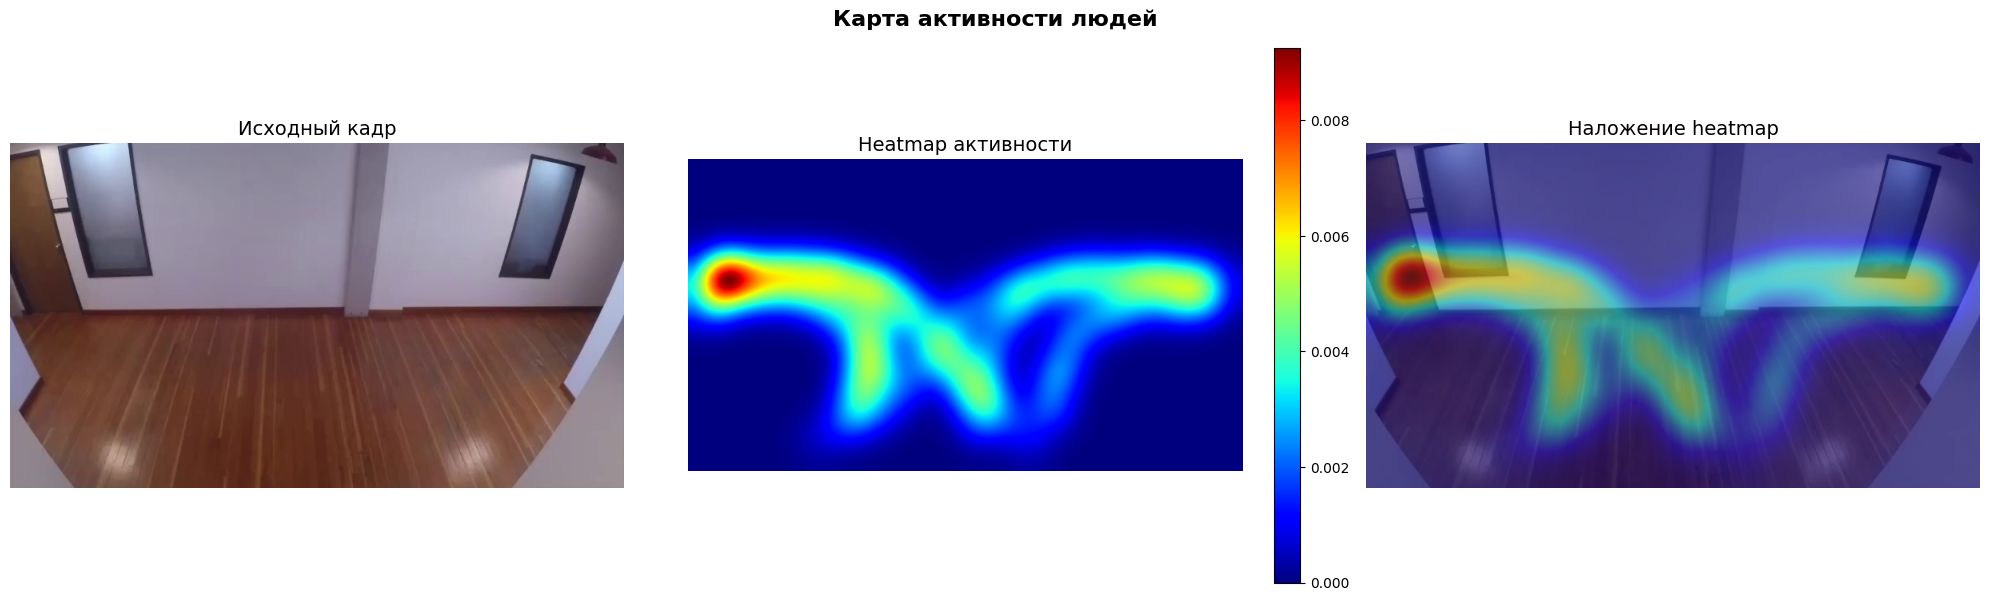

Heatmap сохранён: heatmap_analysis.png


In [68]:
# Применяем гауссово размытие
heatmap_smooth = gaussian_filter(heatmap_accum, sigma=HEATMAP_BLUR_SIGMA)

if heatmap_smooth.max() > 0:
    heatmap_norm = (heatmap_smooth / heatmap_smooth.max() * 255).astype(np.uint8)
else:
    heatmap_norm = np.zeros_like(heatmap_smooth, dtype=np.uint8)

# Цветовая карта
heatmap_color = cv2.applyColorMap(heatmap_norm, cv2.COLORMAP_JET)

# Наложение на первый кадр видео
cap_temp = cv2.VideoCapture(VIDEO_PATH)
ret, first_frame = cap_temp.read()
cap_temp.release()

if ret:
    overlay_heatmap = cv2.addWeighted(first_frame, 0.5, heatmap_color, 0.5, 0)

    fig, axes = plt.subplots(1, 3, figsize=(20, 6))

    axes[0].imshow(cv2.cvtColor(first_frame, cv2.COLOR_BGR2RGB))
    axes[0].set_title('Исходный кадр', fontsize=14)
    axes[0].axis('off')

    im = axes[1].imshow(heatmap_smooth, cmap='jet', interpolation='bilinear')
    axes[1].set_title('Heatmap активности', fontsize=14)
    axes[1].axis('off')
    plt.colorbar(im, ax=axes[1], fraction=0.046)

    axes[2].imshow(cv2.cvtColor(overlay_heatmap, cv2.COLOR_BGR2RGB))
    axes[2].set_title('Наложение heatmap', fontsize=14)
    axes[2].axis('off')

    plt.suptitle('Карта активности людей', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.savefig('heatmap_analysis.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Heatmap сохранён: heatmap_analysis.png")
else:
    print("Не удалось прочитать первый кадр видео.")

## 9. Аналитика и графики

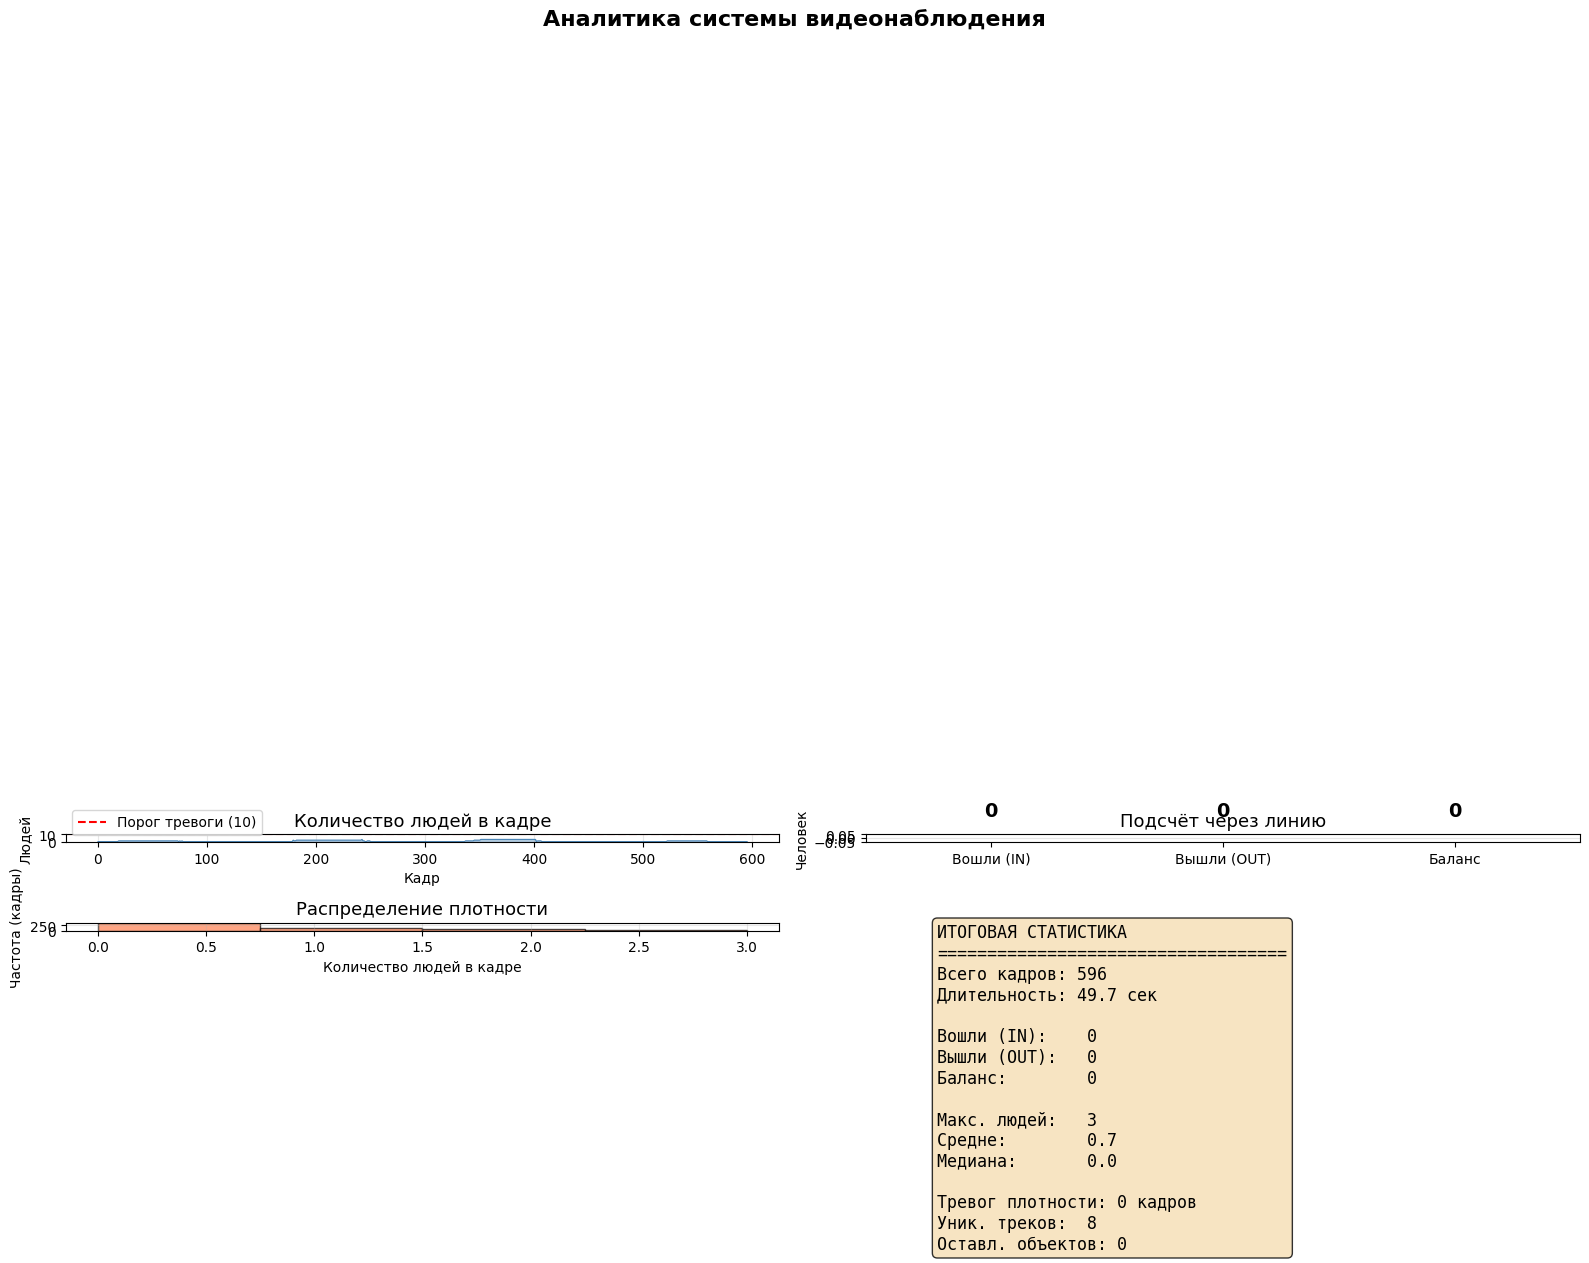

Дашборд сохранён: analytics_dashboard.png


In [69]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Плотность людей по кадрам
axes[0, 0].plot(density_log, color='steelblue', linewidth=0.8)
axes[0, 0].axhline(y=DENSITY_ALARM_THRESHOLD, color='red', linestyle='--',
                    label=f'Порог тревоги ({DENSITY_ALARM_THRESHOLD})')
axes[0, 0].fill_between(range(len(density_log)), density_log, alpha=0.3, color='steelblue')
axes[0, 0].set_title('Количество людей в кадре', fontsize=13)
axes[0, 0].set_xlabel('Кадр')
axes[0, 0].set_ylabel('Людей')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Вход/выход
axes[0, 1].bar(['Вошли (IN)', 'Вышли (OUT)', 'Баланс'],
               [count_in, count_out, count_in - count_out],
               color=['#2ecc71', '#e74c3c', '#3498db'])
axes[0, 1].set_title('Подсчёт через линию', fontsize=13)
axes[0, 1].set_ylabel('Человек')
for i, v in enumerate([count_in, count_out, count_in - count_out]):
    axes[0, 1].text(i, v + 0.3, str(v), ha='center', fontsize=14, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3, axis='y')

# Гистограмма плотности
if len(density_log) > 0:
    axes[1, 0].hist(density_log, bins=max(1, max(density_log)-min(density_log)+1),
                    color='coral', edgecolor='black', alpha=0.7)
axes[1, 0].set_title('Распределение плотности', fontsize=13)
axes[1, 0].set_xlabel('Количество людей в кадре')
axes[1, 0].set_ylabel('Частота (кадры)')
axes[1, 0].grid(True, alpha=0.3)

# Статистика
axes[1, 1].axis('off')
stats_text = (
    f"ИТОГОВАЯ СТАТИСТИКА\n"
    f"{'='*35}\n"
    f"Всего кадров: {len(density_log)}\n"
    f"Длительность: {len(density_log)/FPS:.1f} сек\n\n"
    f"Вошли (IN):    {count_in}\n"
    f"Вышли (OUT):   {count_out}\n"
    f"Баланс:        {count_in - count_out}\n\n"
    f"Макс. людей:   {max(density_log) if density_log else 0}\n"
    f"Средне:        {np.mean(density_log):.1f}\n"
    f"Медиана:       {np.median(density_log):.1f}\n\n"
    f"Тревог плотности: {len(alarm_frames)} кадров\n"
    f"Уник. треков:  {len(track_history)}\n"
    f"Оставл. объектов: {len(abandoned_alerts)}"
)
axes[1, 1].text(0.1, 0.95, stats_text, transform=axes[1, 1].transAxes,
                fontsize=12, verticalalignment='top', fontfamily='monospace',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

plt.suptitle('Аналитика системы видеонаблюдения', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('analytics_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print("Дашборд сохранён: analytics_dashboard.png")

## 10. Скачивание результатов

In [70]:
from google.colab import files

print("Доступные файлы для скачивания:")
output_files = [
    ('surveillance_web.mp4', 'Обработанное видео'),
    ('heatmap_analysis.png', 'Heatmap активности'),
    ('analytics_dashboard.png', 'Дашборд аналитики'),
]

for fname, desc in output_files:
    if os.path.exists(fname):
        size = os.path.getsize(fname) / (1024*1024)
        print(f"  {fname} ({desc}) — {size:.1f} MB")
    else:
        print(f"  {fname} — не найден")

print("\nСкачивание файлов:")
for fname, desc in output_files:
    if os.path.exists(fname):
        try:
            files.download(fname)
        except Exception as e:
            print(f"  Ошибка при скачивании {fname}: {e}")

Доступные файлы для скачивания:
  surveillance_web.mp4 (Обработанное видео) — 1.7 MB
  heatmap_analysis.png (Heatmap активности) — 0.7 MB
  analytics_dashboard.png (Дашборд аналитики) — 0.1 MB

Скачивание файлов:


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Описание реализованных компонентов

| Компонент | Реализация |
|-----------|------------|
| **Детекция людей** | YOLOv8s, `classes=[0]`, фильтрация по confidence |
| **Трекинг** | ByteTrack через `model.track(persist=True)`, сохранение траекторий |
| **Подсчёт людей** | Горизонтальная линия, отслеживание пересечений IN/OUT по track ID |
| **Оценка плотности** | Подсчёт людей в каждом кадре, лог по времени |
| **Heatmap** | Аккумуляция центров bbox + гауссово размытие → наложение на кадр |

### Дополнительные улучшения

| Компонент | Реализация |
|-----------|------------|
| **Тревога плотности** | Если людей > порога — красная рамка + текст ALARM |
| **Оставленные объекты** | Трекинг не-людей, алерт при неподвижности > N секунд |
| **Направление движения** | Вектор по последним точкам трека → стрелка (8 направлений) |
| **Скорость движения** | Расчёт по пройденным пикселям × масштаб → км/ч |
